# VLISM structure functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from scipy.stats import linregress


from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

plt.rc("font", family="Arial")

## Load data

In [2]:
v1_raw = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
v1_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


In [3]:
v1_res = v1_raw.resample("1d").mean()
v1_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


In [4]:
v2_raw = pd.read_pickle("../data/interim/voyager/voyager2_lism.pkl")
v2_res = v2_raw.resample("1d").mean()
v2_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1518 entries, 2018-11-05 to 2022-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1438 non-null   float32
 1   BR      1438 non-null   float32
 2   BT      1438 non-null   float32
 3   BN      1438 non-null   float32
dtypes: float32(4)
memory usage: 35.6 KB


## Low-res SFs (daily)

In [5]:
lags_v1_lr = np.arange(1, len(v1_res))
lags_v2_lr = np.arange(1, len(v2_res))

In [ ]:
sf_v1_lr = sf_funcs.compute_sf_fast(v1_res[["BR", "BT", "BN"]], lags_v1_lr, [2])
sf_v2_lr = sf_funcs.compute_sf_fast(v2_res[["BR", "BT", "BN"]], lags_v2_lr, [2])

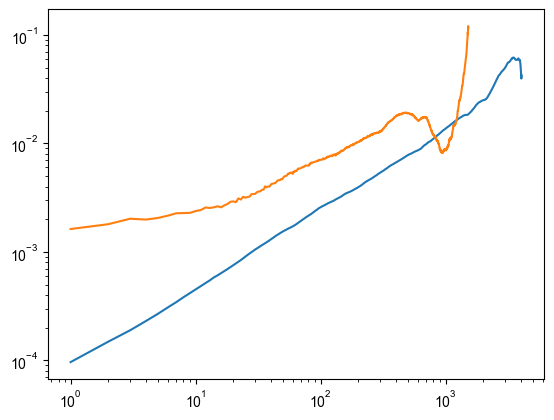

In [7]:
plt.loglog(lags_v1_lr, sf_v1_lr)
plt.loglog(lags_v2_lr, sf_v2_lr)

### Investigating noise

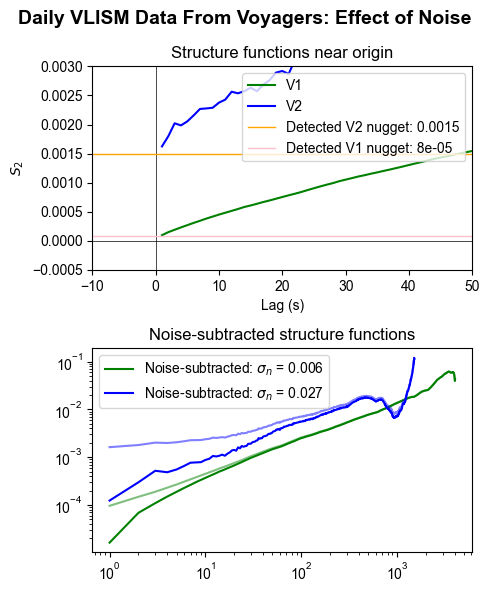

In [58]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6))

ax1.plot(
    lags_v1_lr,
    sf_v1_lr,
    label="V1",
    color="green",
)
ax1.plot(
    lags_v2_lr,
    sf_v2_lr,
    label="V2",
    color="blue",
)

# Set axis limits
ax1.set_xlim(-10, 50)
ax1.set_ylim(-0.0005, 0.003)
# Add horizontal line at y=0
ax1.axhline(0, color="black", linewidth=0.5)
ax1.axvline(0, color="black", linewidth=0.5)

nugget_v2_lr = 0.0015
nugget_v1_lr = 0.00008
sigma_err_v2_lr = np.sqrt(nugget_v2_lr / 2)
sigma_err_v1_lr = np.sqrt(nugget_v1_lr / 2)

ax1.axhline(
    nugget_v2_lr,
    color="orange",
    linestyle="-",
    linewidth=1,
    label=f"Detected V2 nugget: {nugget_v2_lr}",
)
ax1.axhline(
    nugget_v1_lr,
    color="pink",
    linestyle="-",
    linewidth=1,
    label=f"Detected V1 nugget: {nugget_v1_lr}",
)

ax1.legend(loc="upper right")
ax1.set_xlabel("Lag (s)")
ax1.set_ylabel("$S_2$")
ax1.set_title("Structure functions near origin")

ax2.set_title("Noise-subtracted structure functions")
ax2.loglog(lags_v1_lr, sf_v1_lr, color="green", alpha=0.5)
ax2.loglog(
    lags_v1_lr,
    sf_v1_lr - nugget_v1_lr,
    color="green",
    label=f"Noise-subtracted: $\sigma_n$ = {sigma_err_v1_lr:.3f}",
)
ax2.loglog(
    lags_v2_lr,
    sf_v2_lr,
    color="blue",
    alpha=0.5,
)
ax2.loglog(
    lags_v2_lr,
    sf_v2_lr - nugget_v2_lr,
    color="blue",
    label=f"Noise-subtracted: $\sigma_n$ = {sigma_err_v2_lr:.3f}",
)
ax2.legend()

plt.suptitle(
    "Daily VLISM Data From Voyagers: Effect of Noise",
    fontsize=14,
    fontweight="bold",
    x=0.5,
)
plt.tight_layout()

The reported noise level for V2 RTN is 0.06, 0.03, 0.03. I still need to calculate the expected vector SF version. Also, I would have thought this would have disappeared with averaging.

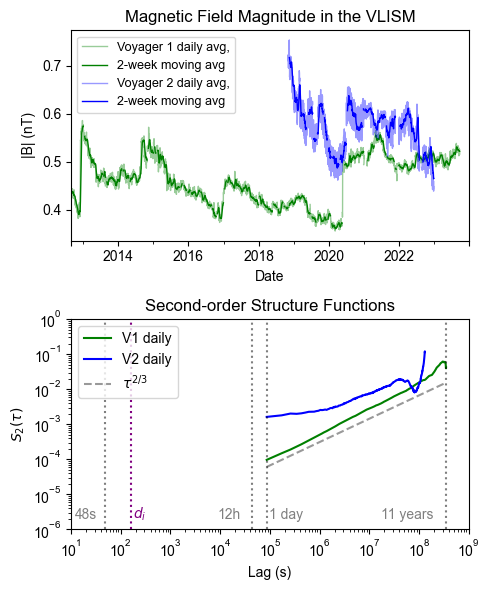

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(5, 6))
v1_res["F1"].plot(ax=ax[0], label="Voyager 1 daily avg,", c="green", lw=1, alpha=0.4)
# Add moving average
v1_res["F1"].rolling(window=14).mean().plot(
    ax=ax[0], label="2-week moving avg", c="green", lw=1
)
v2_res["F1"].plot(ax=ax[0], label="Voyager 2 daily avg,", c="blue", lw=1, alpha=0.4)
# Add moving average
v2_res["F1"].rolling(window=14).mean().plot(
    ax=ax[0], label="2-week moving avg", c="blue", lw=1
)
ax[0].legend(fontsize=9)
ax[0].set_ylabel("|B| (nT)")
ax[0].set_xlabel("Date")

ax[1].plot(lags_v1_lr * 86400, sf_v1_lr, color="green", label="V1 daily")

ax[1].plot(
    lags_v2_lr * 86400,
    sf_v2_lr,
    color="blue",
    label=f"V2 daily",
)


# Plot 2/3 power law
pwrl_range = np.logspace(np.log10(3600*24), np.log10(11 * 365 * 86400), 100)
ax[1].plot(
    pwrl_range,
    0.000000031 * np.power(pwrl_range, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.4,
)


ax[1].legend(loc="upper left")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlim(1e1, 1e9)
ax[1].set_ylim(1e-6, 1e0)
ax[1].set_xlabel("Lag (s)")
ax[1].set_ylabel("$S_2(\\tau)$")
ax[0].set_title("Magnetic Field Magnitude in the VLISM")
ax[1].set_title(f"Second-order Structure Functions")

# Add vertical line at 1 day lag, with annotation
ax[1].axvline(86400, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "1 day",
    xy=(86400 * 1.1, 2e-6),
    fontsize=10,
    alpha=0.5,
)
# Add vertical line at 11 years lag, with annotation
ax[1].axvline(11 * 365 * 86400, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "11 years",
    xy=(11 * 365 * 86400 * 0.05, 2e-6),
    fontsize=10,
    alpha=0.5,
)

ax[1].axvline(48, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "48s",
    xy=(48 * 0.25, 2e-6),
    fontsize=10,
    alpha=0.5,
)

# Add vertical line at 12 hours lag, with annotation
ax[1].axvline(12 * 3600, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "12h",
    xy=(12 * 3600 * 0.2, 2e-6),
    fontsize=10,
    alpha=0.5,
)

ax[1].axvline(160, color="purple", linestyle=":")

ax[1].annotate("$d_i$", xy=(1.1 * 160, 2e-6), fontsize=10, c="purple")

plt.tight_layout()

- V2 SF consistent higher power from clearly larger fluctuations (db/B0 = ?). Having subtracted the noise, it is reasonably monofractal K41 up to about 4e7=1.3 years, at which point it dips to a trough at 8e7 = 2.5 years.
- V1 SF very smooth and monofractal, marginally steeper than K41. 

## High-res SFs (48s)

In [10]:
v1_raw_lint = v1_raw.interpolate(method="linear")
v2_raw_lint = v2_raw.interpolate(method="linear")

In [25]:
1e6*48/(365*60*60*24)

1.5220700152207

In [33]:
v1_length = int(7.5e6) # Can go up to 7.5e6 for V1, 2.7e6 for V2
v2_length = int(2.7e6) # V2 length is 2.7e6
nlags = 200

lags_v1_hr = np.logspace(0, np.log10(v1_length), nlags)
# Convert array to integers
lags_v1_hr = [int(x) for x in lags_v1_hr]
# Drop duplicate lags
lags_v1_hr = np.unique([int(x) for x in lags_v1_hr])

lags_v2_hr = np.logspace(0, np.log10(v2_length), nlags)
# Convert array to integers
lags_v2_hr = [int(x) for x in lags_v2_hr]
# Drop duplicate lags
lags_v2_hr = np.unique([int(x) for x in lags_v2_hr])

In [ ]:
# FOR THE SAKE OF GOOD GP TIME SERIES, CREATING SMALL SFS WITH LINEAR LAGS

lags_v1_hr_linear = np.arange(1, 20000)


sf_v1_hr_linear, sf_v1_hr_gp_linear = sf_funcs.compute_sf_fast(

    v1_raw[["BR", "BT", "BN"]][:20000],
    lags_v1_hr_linear,
    [2],

    return_missing=True

)



sf_v2_hr_linear, sf_v2_hr_gp_linear = sf_funcs.compute_sf_fast(

    v2_raw[["BR", "BT", "BN"]][:20000],
    lags_v1_hr_linear,
    [2],

    return_missing=True,

)

In [49]:
sf_v1_hr_lint_linear = sf_funcs.compute_sf_fast(
    v1_raw_lint[["BR", "BT", "BN"]][:20000], lags_v1_hr_linear, [2]
)

sf_v2_hr_lint_linear = sf_funcs.compute_sf_fast(
    v2_raw_lint[["BR", "BT", "BN"]][:20000], lags_v1_hr_linear, [2]
)

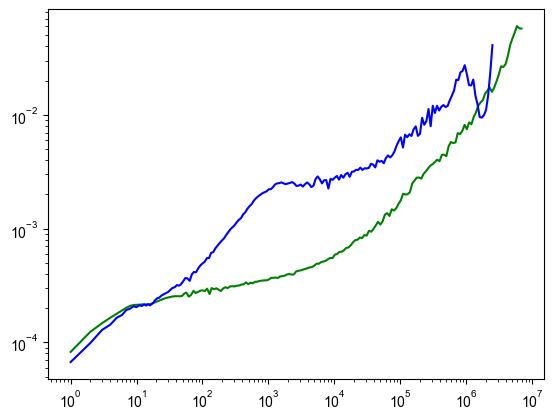

In [34]:
v1_raw_sub = v1_raw[:v1_length]
v2_raw_sub = v2_raw[:v2_length]

sf_v1_hr, sf_v1_hr_gp = sf_funcs.compute_sf_fast(
    v1_raw_sub[["BR", "BT", "BN"]],
    lags_v1_hr,
    [2],
    return_missing=True,
)

sf_v2_hr, sf_v2_hr_gp = sf_funcs.compute_sf_fast(
    v2_raw_sub[["BR", "BT", "BN"]],
    lags_v2_hr,
    [2],
    return_missing=True,
)

plt.loglog(lags_v1_hr, sf_v1_hr, label="V1", c = "green")
plt.loglog(lags_v2_hr, sf_v2_hr, label="V2", c= "blue")

In [16]:
v1_raw_lint_sub = v1_raw_lint[:v1_length]
sf_v1_hr_lint = sf_funcs.compute_sf_fast(
    v1_raw_lint_sub[["BR", "BT", "BN"]],
    lags_v1_hr,
    [2]
)

v2_raw_lint_sub = v2_raw_lint[:v2_length]
sf_v2_hr_lint = sf_funcs.compute_sf_fast(
    v2_raw_lint_sub[["BR", "BT", "BN"]],
    lags_v2_hr,
    [2]
)

### Investigating noise

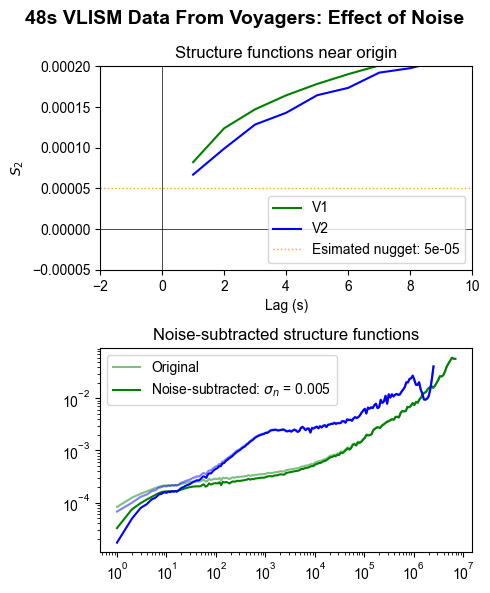

In [63]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6))

ax1.plot(
    lags_v1_hr,
    sf_v1_hr,
    label="V1",
    color="green",
)
ax1.plot(
    lags_v2_hr,
    sf_v2_hr,
    label="V2",
    color="blue",
)

# Set axis limits
ax1.set_xlim(-2, 10)
ax1.set_ylim(-0.00005, 0.0002)
# Add horizontal line at y=8

ax1.axhline(0, color="black", linewidth=0.5)
ax1.axvline(0, color="black", linewidth=0.5)

#nugget_hr = 0.00006
nugget_hr = 0.00005

sigma_err_hr = np.sqrt(nugget_hr / 2)
# sigma_err_hr = 0.035
# nugget_hr = sigma_err_hr ** 2 * 2

ax1.axhline(
    nugget_hr,
    color="orange",
    linestyle=":",
    linewidth=1,
    label=f"Esimated nugget: {nugget_hr}",
)


ax1.legend()
ax1.set_xlabel("Lag (s)")
ax1.set_ylabel("$S_2$")
ax1.set_title("Structure functions near origin")

ax2.set_title("Noise-subtracted structure functions")
ax2.loglog(
    lags_v1_hr,
    sf_v1_hr,
    alpha=0.5,
    color="green",
    label="Original"
)
ax2.loglog(
    lags_v1_hr,
    sf_v1_hr - nugget_hr,
    color="green",
    label=f"Noise-subtracted: $\sigma_n$ = {sigma_err_hr:.3f}",
)
ax2.loglog(
    lags_v2_hr,
    sf_v2_hr,
    color="blue",
    alpha=0.5,
)
ax2.loglog(
    lags_v2_hr,
    sf_v2_hr - nugget_hr,
    color="blue",
)
ax2.legend()

plt.suptitle(
    "48s VLISM Data From Voyagers: Effect of Noise",
    fontsize=14,
    fontweight="bold",
    x=0.5,
)
plt.tight_layout()

The *component*-wise error is reported to be 0.005nT. For the vector magnitude, we expect 0.009 (but we aren't computing the SF from the magnitude right?). As shown below, this would give us a nugget of about 0.00016.

### Investigating gaps and interpolation

In [18]:
data_plot = v1_raw["F1"]["2016-01-28 10:30":"2016-01-31 10:30"]
data = data_plot.dropna()

# Find gaps (normal interval is 48 seconds, so gaps are longer)
time_diffs = data.index.to_series().diff()
gap_threshold = pd.Timedelta(
    seconds=48 * 1
)  # Consider gaps 3x normal interval or longer 

# Find all gaps above threshold
gaps = time_diffs[time_diffs > gap_threshold]

# For each gap, store start time, end time, and duration
gap_info = []
for gap_end_idx in gaps.index:
    gap_start = data.index[data.index.get_loc(gap_end_idx) - 1]  # Previous data point
    gap_end = gap_end_idx
    gap_duration = gaps[gap_end_idx]
    gap_info.append((gap_start, gap_end, gap_duration))

# Sort by duration and get the 2 largest
gap_info.sort(key=lambda x: x[2], reverse=True)
largest_gaps = gap_info[:4]
smallest_gaps = gap_info[-4:]

# Create list of time ranges covered by the largest gaps
annotated_ranges = []
for gap_start, gap_end, gap_duration in largest_gaps:
    annotated_ranges.append((gap_start, gap_end))

# Find NA values in the data
na_times = data_plot[data_plot.isna()].index

# Filter out NA values that fall within annotated gaps
na_outside_gaps = []
for na_time in na_times:
    is_in_gap = False
    for gap_start, gap_end in annotated_ranges:
        if gap_start <= na_time <= gap_end:
            is_in_gap = True
            break
    if not is_in_gap:
        if na_time > data.index[0] and na_time < data.index[-1]:
            # Only add NA times that are within the data range
            na_outside_gaps.append(na_time)

### Interactive investigation

In [19]:
# import plotly.graph_objects as go

# fig = go.Figure()

# # Plot the data
# fig.add_trace(go.Scatter(
#     x=data_plot.index, y=data_plot.values,
#     mode='lines',
#     line=dict(color='black', width=1),
#     name='MAG data'
# ))

# # Add red vertical lines for NA values outside of annotated gaps
# for na_time in na_outside_gaps:
#     fig.add_vline(
#         x=na_time,
#         line_color='red',
#         line_width=1,
#         opacity=0.6
#     )

# fig.update_layout(
#     title="3 days of MAG data from Voyager 1",
#     xaxis_title="Time",
#     yaxis_title="|B| (nT)",
#     showlegend=False,
#     height=400,
#     width=700
# )
# fig.show()

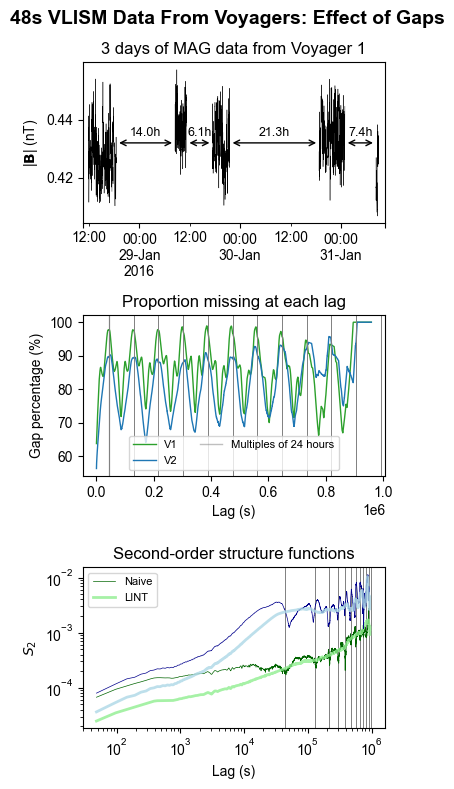

In [72]:
fig, (ax3, ax2, ax1) = plt.subplots(3, 1, figsize=(4, 8))

data_plot.plot(ax=ax3, title="3 days of MAG data from Voyager 1", lw=0.3, color="black")

# Annotate the gaps
for gap_start, gap_end, gap_duration in largest_gaps:
    # Calculate middle of the gap
    gap_middle = gap_start + (gap_end - gap_start) / 2
    gap_duration_hours = gap_duration.total_seconds() / 3600

    # Find appropriate y-position for the annotation
    y_min, y_max = ax3.get_ylim()
    y_pos = (y_min + y_max) / 2

    # Add horizontal line with arrows at both ends spanning the gap
    ax3.annotate(
        "",
        xy=(gap_end, y_pos),
        xytext=(gap_start, y_pos),
        arrowprops=dict(arrowstyle="<->", color="black", lw=1),
    )

    # Add text annotation above the line
    ax3.annotate(
        f"{gap_duration_hours:.1f}h",
        xy=(gap_middle, y_pos),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        # bbox=dict(boxstyle="round,pad=0.3", facecolor="gray", alpha=0.4),
        fontsize=9,
    )
ax3.set_ylabel("|$\\bf{B}$| (nT)")

# Add red vertical lines for NA values outside of annotated gaps
# for na_time in na_outside_gaps:
#     ax3.axvline(x=na_time, color="red", linestyle="-", alpha=0.6, linewidth=1)

# Sample size plot (top, now ax2)
ax2.plot(lags_v1_hr_linear * 48, sf_v1_hr_gp_linear, color="tab:green", lw=1, label="V1")
ax2.plot(lags_v1_hr_linear * 48, sf_v2_hr_gp_linear, color="tab:blue", lw=1, label="V2")
ax2.set_ylabel("Gap percentage (%)")

# Add vertical lines at multiples of 12 hours to both axes
for i in np.arange(0, 12, 1):
    for ax_ in (ax2, ax1):
        ax_.axvline((12+i * 24) * 3600, color="gray", lw=0.7)

# Add one vertical line to the legend
ax2.axvline(
    12 * 3600, color="gray", lw=1, alpha=0.5, label="Multiples of 24 hours"
)
# Add legend to the sample size plot
ax2.legend(framealpha=0.8, loc="lower center", ncols=2,
           fontsize=8
              )

ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v1_hr_linear,
    color="darkgreen",
    label="Naive",
    lw=0.5,
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v1_hr_lint_linear,
    color="lightgreen",
    label="LINT",
    lw=2,
    alpha=0.8,
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v2_hr_linear,
    color="darkblue",
    lw=0.5,
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v2_hr_lint_linear,
    color="lightblue",
    lw=2,
    alpha=0.8,
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel("$S_2$")
ax1.set_xlabel("Lag (s)")
ax2.set_xlabel("Lag (s)")

ax1.set_title("Second-order structure functions")
ax2.set_title("Proportion missing at each lag")
plt.suptitle(
    "48s VLISM Data From Voyagers: Effect of Gaps",
    fontsize=14,
    fontweight="bold",
    x=0.55,
    )
ax1.legend(fontsize=8)
plt.tight_layout()
plt.savefig("vlism_hr_sfs_gaps.png", dpi=300, bbox_inches="tight")

- Clear periodicity of gaps is evident in plot of GP as function of lag. 
- V1 shows secondary humps,due to prevalence of 20 hour gaps as well; see image below. 

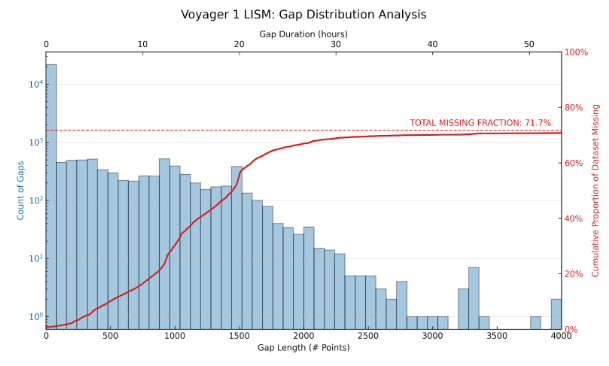


## Combined plot

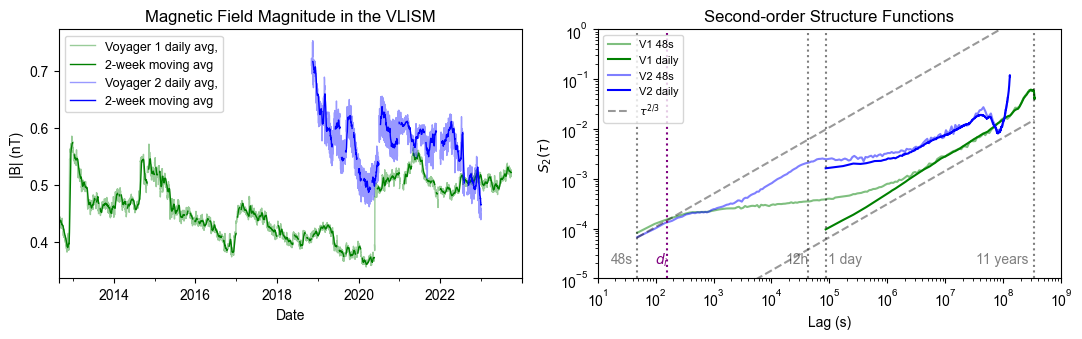

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
v1_res["F1"].plot(ax=ax[0], label="Voyager 1 daily avg,", c="green", lw=1, alpha=0.4)
# Add moving average
v1_res["F1"].rolling(window=14).mean().plot(ax=ax[0], label="2-week moving avg", c="green", lw=1)
v2_res["F1"].plot(ax=ax[0], label="Voyager 2 daily avg,", c="blue", lw=1, alpha=0.4)
# Add moving average
v2_res["F1"].rolling(window=14).mean().plot(ax=ax[0], label="2-week moving avg", c="blue", lw=1)
ax[0].legend(fontsize=9)
ax[0].set_ylabel("|B| (nT)")
ax[0].set_xlabel("Date")

ax[1].plot(
    lags_v1_hr * 48,
    sf_v1_hr,
    color="green",
    alpha=0.5,
    label=f"V1 48s",
)
ax[1].plot(lags_v1_lr * 86400, sf_v1_lr, color="green", label="V1 daily")

ax[1].plot(
    lags_v2_hr * 48,
    sf_v2_hr,
    color="blue",
    alpha=0.5,
    label=f"V2 48s",
)

ax[1].plot(
    lags_v2_lr * 86400,
    sf_v2_lr,
    color="blue",
    label=f"V2 daily",
)


# Plot 2/3 power law
pwrl_range = np.logspace(np.log10(48), np.log10(11 * 365 * 86400), 100)
ax[1].plot(
    pwrl_range,
    0.000000031 * np.power(pwrl_range, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.4,
)

pwrl_range = np.logspace(np.log10(48), np.log10(11 * 365 * 86400), 100)
ax[1].plot(
    pwrl_range,
    0.000005 * np.power(pwrl_range, 2 / 3),
    color="black",
    linestyle="--",
    alpha=0.4,
)

ax[1].legend(loc="upper left", fontsize=8)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlim(1e1, 1e9)
ax[1].set_ylim(1e-5, 1e0)
ax[1].set_xlabel("Lag (s)")
ax[1].set_ylabel("$S_2(\\tau)$")
ax[0].set_title("Magnetic Field Magnitude in the VLISM")
ax[1].set_title(f"Second-order Structure Functions")

# Add vertical line at 1 day lag, with annotation
ax[1].axvline(86400, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "1 day",
    xy=(86400*1.1, 2e-5),
    fontsize=10,
    alpha=0.5,
)
# Add vertical line at 11 years lag, with annotation
ax[1].axvline(11 * 365 * 86400, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "11 years",
    xy=(11 * 365 * 86400*0.1, 2e-5),
    fontsize=10,
    alpha=0.5,
)

ax[1].axvline(48, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "48s",
    xy=(48 * 0.35, 2e-5),
    fontsize=10,
    alpha=0.5,
)

# Add vertical line at 12 hours lag, with annotation
ax[1].axvline(12 * 3600, color="black", linestyle=":", alpha=0.5)
ax[1].annotate(
    "12h",
    xy=(12 * 3600 * 0.4, 2e-5),
    fontsize=10,
    alpha=0.5,
)

ax[1].axvline(160, color="purple", linestyle=":")

ax[1].annotate("$d_i$", xy=(0.6 * 160, 2e-5), fontsize=10, c="purple")
plt.tight_layout()
plt.savefig("vlism_sfs.png", dpi=300, bbox_inches="tight")

- HR SFs eventually match the LR versions, later for V2, probably due to smaller sample size.
- V1 flattens out considerably at smaller scales.
- V2 flattens out to hump at around 12h-1 day.

Potentially relevant? 

- [Statistical inference of random field auto-correlation structure from multiple sets of incomplete and sparse measurements using Bayesian compressive sampling-based bootstrapping](https://www.sciencedirect.com/science/article/pii/S0888327019300652#s0065)
- [Interpolation uncertainty of atmospheric temperature profiles](https://amt.copernicus.org/articles/13/6445/2020/amt-13-6445-2020.html)